In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("healthcare_patient_analytics_seaborn.csv")

print(df.head())
print(df.info())

   patient_id        visit_date age_group  gender region        department  \
0           1  01-01-2022 00:00     31-45    Male   West  General Medicine   
1           2  01-01-2022 01:00       60+  Female   West       Orthopedics   
2           3  01-01-2022 02:00     46-60    Male  South        Pediatrics   
3           4  01-01-2022 03:00     31-45  Female  North         Neurology   
4           5  01-01-2022 04:00     18-30  Female  North         Neurology   

  treatment_type visit_type  length_of_stay_days  treatment_cost  \
0     Medication  Emergency                  5.8           59151   
1        Surgery    Routine                  5.1           30272   
2    Observation    Routine                  7.9           67498   
3     Medication    Routine                  5.0           29896   
4        Therapy    Routine                  0.0           36208   

   recovery_score  readmission_risk  
0              59              0.12  
1              97              0.11  
2       

In [10]:
print(df.isnull().sum())
df = df.drop_duplicates()

patient_id             0
visit_date             0
age_group              0
gender                 0
region                 0
department             0
treatment_type         0
visit_type             0
length_of_stay_days    0
treatment_cost         0
recovery_score         0
readmission_risk       0
dtype: int64


In [16]:
categorical_cols = [
    'age_group',
    'gender',
    'region',
    'department',
    'treatment_type',
    'visit_type'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
df['risk_category'] = (
    df['readmission_risk'] >= 0.5).astype(int)

In [24]:
X = df[
[
'age_group',
'gender',
'region',
'department',
'treatment_type',
'visit_type',
'length_of_stay_days',
'treatment_cost',
'recovery_score'
]
]

y = df['risk_category']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
y_pred = model.predict(X_test)

In [32]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.908


In [34]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       908
           1       0.00      0.00      0.00        92

    accuracy                           0.91      1000
   macro avg       0.45      0.50      0.48      1000
weighted avg       0.82      0.91      0.86      1000



C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


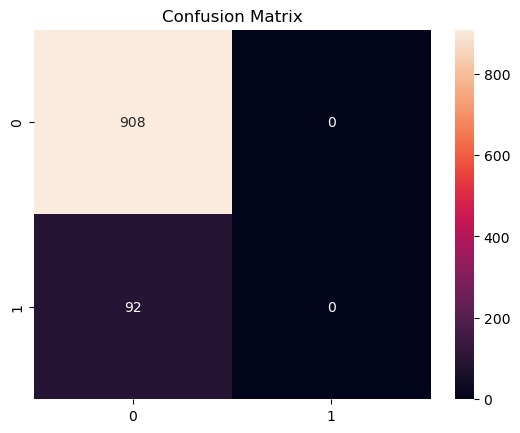

In [36]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

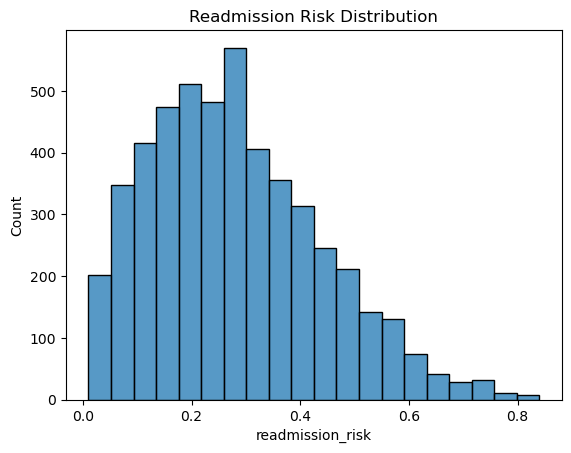

In [38]:
sns.histplot(
    df['readmission_risk'],
    bins=20
)

plt.title("Readmission Risk Distribution")
plt.show()

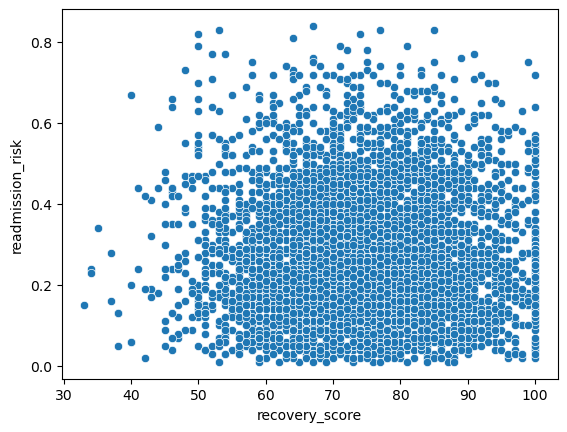

In [40]:
sns.scatterplot(
    x='recovery_score',
    y='readmission_risk',
    data=df
)

plt.show()

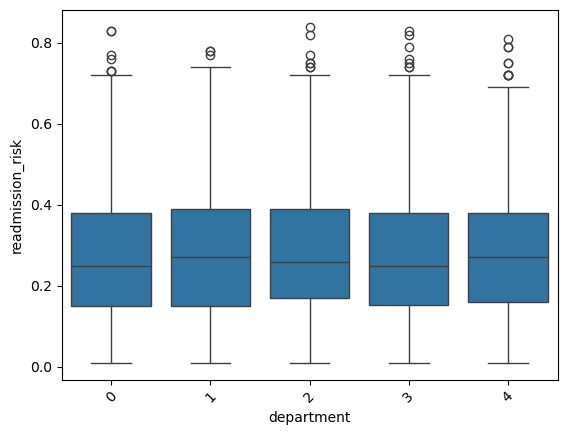

In [42]:
sns.boxplot(
    x='department',
    y='readmission_risk',
    data=df
)

plt.xticks(rotation=45)
plt.show()